## Part 5a ##

    qsat = 4.72 mmol/g
    k(263) = 6.75e-06 1/Pa
    k(303) = 1.48e-06 1/Pa
    k(343) = 5.16e-07 1/Pa

--- Van't Hoff Analysis ---
Slope (m) = 2905.4431
Y-intercept (c) = -22.9712

Calculated Parameters:
k0: 1.0562e-10 1/Pa
Delta H: -24.1559 kJ/mol


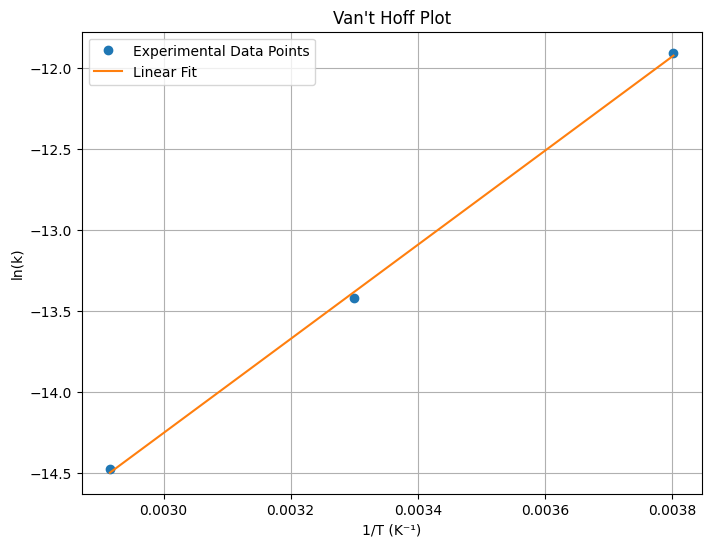


--- Henry's Coefficient Calculation ---
Henry's Coefficient at 263 K: 3.1860e-05 mmol/(g·Pa)
Henry's Coefficient at 303 K: 6.9856e-06 mmol/(g·Pa)
Henry's Coefficient at 343 K: 2.4355e-06 mmol/(g·Pa)

--- Discussion of Henry's Coefficient Trend ---
As the temperature increases, the Henry's coefficient decreases.
This is expected because adsorption is an exothermic process,
and a higher temperature reduces the affinity of the gas for the adsorbent,
resulting in a lower uptake at low pressures.
This is consistent with the principle of Le Châtelier.


In [9]:
# PART A

import numpy as np
import matplotlib.pyplot as plt

def calculate_langmuir_parameters(temperatures, k_values):
    """
    Calculates k0 and delta H from temperature-dependent k values
    using the linearized Van't Hoff equation.

    The Van't Hoff equation is:
    ln(k) = ln(k0) - (delta H / R) * (1/T)

    This is in the form of a linear equation y = mx + c, where:
    y = ln(k)
    x = 1/T
    m = -delta H / R (the slope)
    c = ln(k0) (the y-intercept)

    Args:
        temperatures (list or np.array): A list of temperatures in Kelvin (K).
        k_values (list or np.array): A list of equilibrium constants (k) at
                                     each corresponding temperature.

    Returns:
        tuple: A tuple containing the calculated k0 and delta H values.
    """
    # Ideal gas constant R in kJ/(mol·K)
    # The assignment uses kJ/mol for delta H, so we use this value for R.
    R = 0.008314  # kJ/(mol·K)

    # Convert temperatures and k values for the linear plot
    inv_T = 1 / np.array(temperatures)
    ln_k = np.log(np.array(k_values))

    # Perform linear regression using numpy's polyfit
    # The result is [slope, intercept]
    slope, intercept = np.polyfit(inv_T, ln_k, 1)

    # Calculate delta H from the slope
    delta_H = -slope * R

    # Calculate k0 from the y-intercept
    k0 = np.exp(intercept)

    # Print the results
    print("--- Van't Hoff Analysis ---")
    print(f"Slope (m) = {slope:.4f}")
    print(f"Y-intercept (c) = {intercept:.4f}")
    print("\nCalculated Parameters:")
    print(f"k0: {k0:.4e} 1/Pa")
    print(f"Delta H: {delta_H:.4f} kJ/mol")

    # Optional: Plot the data to visualize the linear fit
    plt.figure(figsize=(8, 6))
    plt.plot(inv_T, ln_k, 'o', label='Experimental Data Points')
    plt.plot(inv_T, slope * inv_T + intercept, '-', label='Linear Fit')
    plt.xlabel('1/T (K⁻¹)')
    plt.ylabel('ln(k)')
    plt.title('Van\'t Hoff Plot')
    plt.legend()
    plt.grid(True)
    plt.show()

    return k0, delta_H

# Data provided from the Langmuir isotherm fitting
temperatures_data = [263, 303, 343]  # in K
k_values_data = [6.75e-06, 1.48e-06, 5.16e-07]  # in 1/Pa

# Call the function with the provided data
k0_result, delta_H_result = calculate_langmuir_parameters(temperatures_data, k_values_data)

# PART B


def calculate_henry_coefficient(q_sat, temperatures, k_values):
    """
    Calculates and discusses the Henry's coefficient for each temperature.

    Args:
        q_sat (float): The saturation loading in mmol/g.
        temperatures (list or np.array): A list of temperatures in Kelvin (K).
        k_values (list or np.array): A list of equilibrium constants (k) at
                                     each corresponding temperature.
    """
    # This line prints a header for the output.
    print("\n--- Henry's Coefficient Calculation ---")
    henry_coefficients = []
    # This loop iterates through the temperatures and k values.
    for T, k in zip(temperatures, k_values):
        # This line calculates the Henry's coefficient.
        kh = q_sat * k
        henry_coefficients.append(kh)
        # This line prints the calculated value for each temperature.
        print(f"Henry's Coefficient at {T} K: {kh:.4e} mmol/(g·Pa)")

    # This line prints a header for the discussion.
    print("\n--- Discussion of Henry's Coefficient Trend ---")
    # The following lines provide the discussion of the trend.
    print("As the temperature increases, the Henry's coefficient decreases.")
    print("This is expected because adsorption is an exothermic process,")
    print("and a higher temperature reduces the affinity of the gas for the adsorbent,")
    print("resulting in a lower uptake at low pressures.")
    print("This is consistent with the principle of Le Châtelier.")
    

# The q_sat data was added to the main script's data section.
q_sat_data = 4.72 # mmol/g

# The call to the new function was added at the end of the script.
calculate_henry_coefficient(q_sat_data, temperatures_data, k_values_data)
